In [2]:
# data is stored in google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive')

['Getting started.pdf',
 'Untitled spreadsheet (2).gsheet',
 'Deole_Sopan Matilda Problem.mp4',
 'Untitled document (1).gdoc',
 'case. 1110.xlsx',
 'case. 1110 (1).xlsx',
 'Colab Notebooks',
 'train split - test',
 'team_charter_draft .docx',
 'snowball.csv',
 'snowballstemmed.csv',
 '2022 Business of Self Care Waiver_01.pdf',
 '2022 Business of Self Care Waiver_01 (1).gdoc',
 '2022 Business of Self Care Waiver_01.gdoc',
 'image001.png',
 'imdb_data.csv',
 'variables',
 'assets',
 'keras_metadata.pb',
 'saved_model.pb',
 'saved_model',
 'political_orientation_data.json',
 'political_orientation_data.csv',
 '509_assignment1_train_data.json',
 '509_assignment1_train_data.zip',
 'Basanthi.Resume.Updated.pdf',
 'Cohort A_Team_A11_Capstone (1).pdf',
 'Cohort A_Team_A11_capstone (1).pptx',
 'CohortA_Team11_FinalProject_Report.pdf',
 'CohortA_Team11_FinalProject_Deck (1).pptx',
 'Basanthi Gorijala Green Belt (1).pdf',
 'labeling.gsheet',
 'Table Au.docx',
 '2019_2020 Webster.xlsx',
 'greendat

In [4]:
# basic import of all modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print('all modules imported successfully')

all modules imported successfully


In [5]:
#load data from drive
df=pd.read_csv('/content/drive/MyDrive/data.csv' , encoding='latin-1')
print("Shape :", df.shape)  # rows x columns
print("columns : " , df.columns.tolist())  # column names
df.head() # first 5 rows

Shape : (541909, 8)
columns :  ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
# EDA
print(" /////data type/////// " )
print( df.dtypes)
print ("///////////Missing values///////// " )
print(df.isnull().sum())
print("///////////basic stats////////// " )
print( df.describe())

 /////data type/////// 
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object
///////////Missing values///////// 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
///////////basic stats////////// 
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [7]:
# EDA - Cleanup
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) # convert date column to date time
df['Year'] = df['InvoiceDate'].dt.year # extract year
df['Month'] = df['InvoiceDate'].dt.month #extract month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M') #convert date to monthly period
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')] # rows with invoice number starting with C are removed as they are cancelled orders
df = df.dropna(subset=['CustomerID']) # remove rows with no customer ID
df['revenue'] = df ['Quantity'] * df['UnitPrice'] # create revenue columm
print(" data shape : " , df.shape)




 data shape :  (397924, 12)


In [8]:
df['Country'].unique()


array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [10]:
#regular experiment
# treatment vs control group. treatment group has users from UK where as control group has users from major european countries .
# treatment group is exposed to ads

eu_countries = ['Germany', 'France', 'Netherlands', 'Belgium', 'Switzerland']

eu_customers = df[df['Country'].isin(eu_countries)]['CustomerID'].unique()
uk_customers= df[df['Country']=='United Kingdom']['CustomerID'].unique()

print("uk_customers (treatment) :" , len(uk_customers))
print("eu_customers (contol) :" , len(eu_customers))

df['treatment'] = df['Country'].apply ( lambda x : 1 if x =='United Kingdom' else (0 if x in eu_countries else None)) # treatment flag

df_did = df[df['treatment'].notna()].copy() #filtering out countries that are not in either eu list or UK
print("total users :" , len(df_did) )
print("treatment users : " , len(df_did[df_did['treatment']==1]))
print("control group users :" , len(df_did[df_did['treatment']==0]))


uk_customers (treatment) : 3921
eu_customers (contol) : 236
total users : 377965
treatment users :  354345
control group users : 23620


In [16]:
#intervention point gonna be nov 2011
# pre-treatment period will be jan - oct of 2011
# psot period will be nov 2011- dec 2011
df_did['post'] = df_did['InvoiceDate'].apply( lambda x : 1 if (x.year ==2011 and x.month >= 11) else 0 )

df_did = df_did[df_did['Year']==2011].copy() # filtering data only for 2011

print("pre period : " , len(df_did[df_did['post']==0]))
print("post period : " , len(df_did[df_did['post']==1]))
print(df_did.groupby(['treatment' , 'post']).size())

pre period :  274144
post period :  78715
treatment  post
0.0        0        18352
           1         4105
1.0        0       255792
           1        74610
dtype: int64


In [19]:
#monthly revenue per customer per group

mon_revenue= df_did.groupby(['CustomerID' , 'YearMonth' , 'treatment' , 'post' ])['revenue'].sum().reset_index()

mon_revenue.columns = ['CustomerID' , 'YearMonth' , 'treatment' , 'post' , 'mon_revenue']

# avg revenue by group and period

avg_revenue = mon_revenue.groupby(['YearMonth' , 'treatment'])['mon_revenue'].mean().reset_index()

print("monthly revenue aggregated : " )
print( avg_revenue.head(10))

monthly revenue aggregated : 
  YearMonth  treatment  mon_revenue
0   2011-01        0.0  1111.559167
1   2011-01        1.0   683.446770
2   2011-02        0.0   977.551277
3   2011-02        1.0   523.793270
4   2011-03        0.0  1011.088214
5   2011-03        1.0   530.907489
6   2011-04        0.0   592.574524
7   2011-04        1.0   522.396864
8   2011-05        0.0  1143.396667
9   2011-05        1.0   573.356362


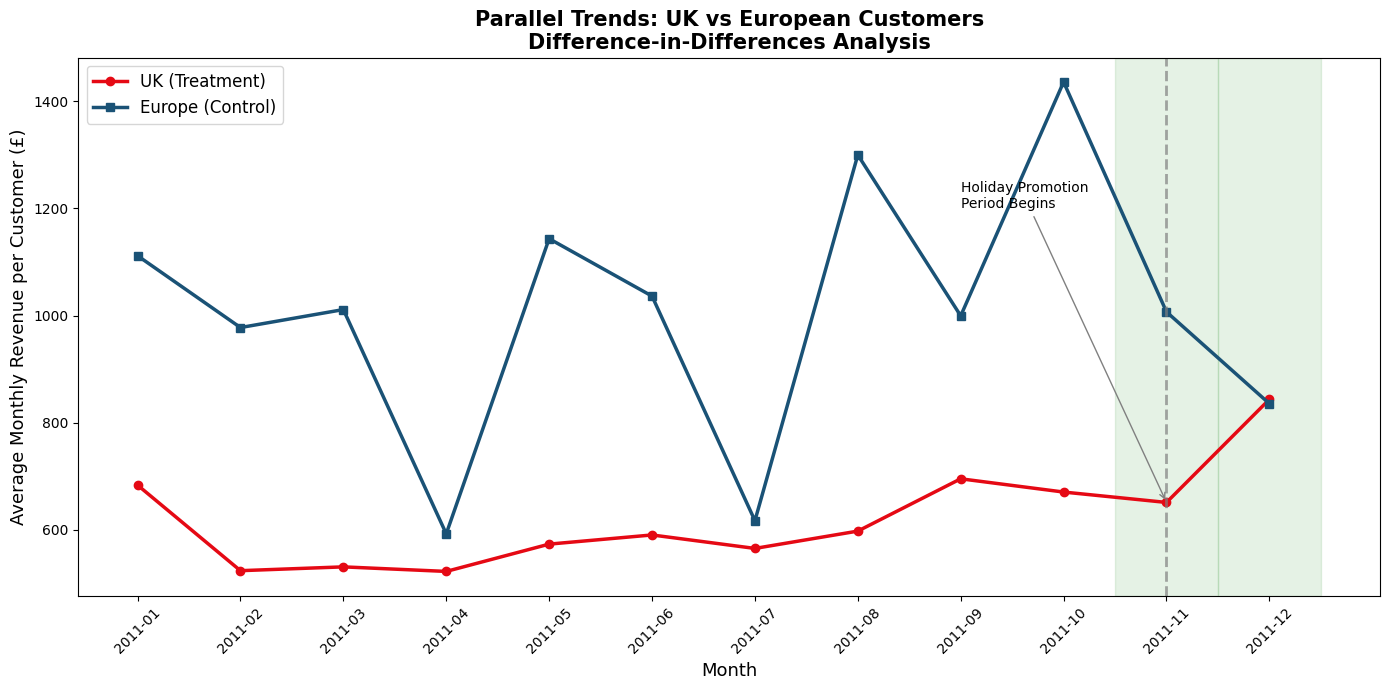

  Plot saved!


In [22]:
import matplotlib.patches as mpacthes

# differentiate treatment and control group

treatment = avg_revenue[avg_revenue['treatment']==1.0]
control = avg_revenue[avg_revenue['treatment']==0.0]

# yearmonth conversion to string
treatment = treatment.copy()
control= control.copy()
treatment['yearmonth_str'] = treatment['YearMonth'].astype(str)
control['yearmonth_str'] = control['YearMonth'].astype(str)

# create a plot

fig , ax = plt.subplots(figsize=(14,7))
# Plot lines
ax.plot(treatment['yearmonth_str'],
        treatment['mon_revenue'],
        color='#E50914', linewidth=2.5,
        marker='o', markersize=6, label='UK (Treatment)')

ax.plot(control['yearmonth_str'],
        control['mon_revenue'],
        color='#1A5276', linewidth=2.5,
        marker='s', markersize=6, label='Europe (Control)')

# Add vertical line at intervention point
ax.axvline(x='2011-11', color='gray',
           linestyle='--', linewidth=2, alpha=0.7)

# Add shading for post period
months = treatment['yearmonth_str'].tolist()
post_start = months.index('2011-11')
for i in range(post_start, len(months)):
    ax.axvspan(i-0.5, i+0.5, alpha=0.1, color='green')

# Labels and formatting
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Average Monthly Revenue per Customer (£)', fontsize=13)
ax.set_title('Parallel Trends: UK vs European Customers\nDifference-in-Differences Analysis',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.tick_params(axis='x', rotation=45)

# Add annotation
ax.annotate('Holiday Promotion\nPeriod Begins',
            xy=('2011-11', treatment[treatment['yearmonth_str']=='2011-11']['mon_revenue'].values[0]),
            xytext=('2011-09', 1200),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('parallel_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Plot saved!")

In [24]:
import statsmodels.formula.api as smf

#did regression

did_model = smf.ols('mon_revenue ~ treatment + post + treatment :post',data = mon_revenue).fit()
print(did_model.summary())
print("="*50)
print("DiD ESTIMATE (Causal Effect):")
print(f"β3 (Treatment x Post): {did_model.params['treatment:post']:.2f}") # this represents the did estimate - causal effect
print(f"P-value: {did_model.pvalues['treatment:post']:.4f}")
print(f"95% CI: [{did_model.conf_int().loc['treatment:post'][0]:.2f}, "
      f"{did_model.conf_int().loc['treatment:post'][1]:.2f}]")
print("="*50)


                            OLS Regression Results                            
Dep. Variable:            mon_revenue   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.925
Date:                Fri, 01 May 2026   Prob (F-statistic):           2.82e-05
Time:                        18:32:26   Log-Likelihood:            -1.0820e+05
No. Observations:               11729   AIC:                         2.164e+05
Df Residuals:                   11725   BIC:                         2.164e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1058.2958     98.635     10.

Based on the above result it is clear that , did analysis is positive but statistically insignificant of 197 per customer. There is high variance in spending behaviour due to wide range of confidence intervals. Due to this, further segmentation is required.

In [27]:
# segment by customer value
pre_period = mon_revenue[mon_revenue['post'] == 0]
median_spend = pre_period.groupby('CustomerID')['mon_revenue'].mean().median()

high_value = pre_period[pre_period['mon_revenue'] >= median_spend]['CustomerID'].unique()
low_value = pre_period[pre_period['mon_revenue'] < median_spend]['CustomerID'].unique()

mon_revenue['Customer_Segment'] = mon_revenue['CustomerID'].apply(
    lambda x: 'High Value' if x in high_value else 'Low Value'
)

# Run DiD for each segment
for segment in ['High Value', 'Low Value']:
    segment_data = mon_revenue[mon_revenue['Customer_Segment'] == segment]
    model = smf.ols(
        'mon_revenue ~ treatment + post + treatment:post',
        data=segment_data
    ).fit()

    coef = model.params['treatment:post']
    pval = model.pvalues['treatment:post']
    print(f"\n{segment} Customers:")
    print(f"DiD Estimate: £{coef:.2f}")
    print(f"P-value: {pval:.4f}")
    print(f"Significant: {'YES ' if pval < 0.05 else 'NO '}")


High Value Customers:
DiD Estimate: £139.80
P-value: 0.5811
Significant: NO 

Low Value Customers:
DiD Estimate: £42.52
P-value: 0.9441
Significant: NO 


**As there is structural differences between UK and EU customers DiD maynot be the right. Need more robust approach as this will match customers well like pairing each UK customer with a similar European customer based on pre-period spending patterns  **

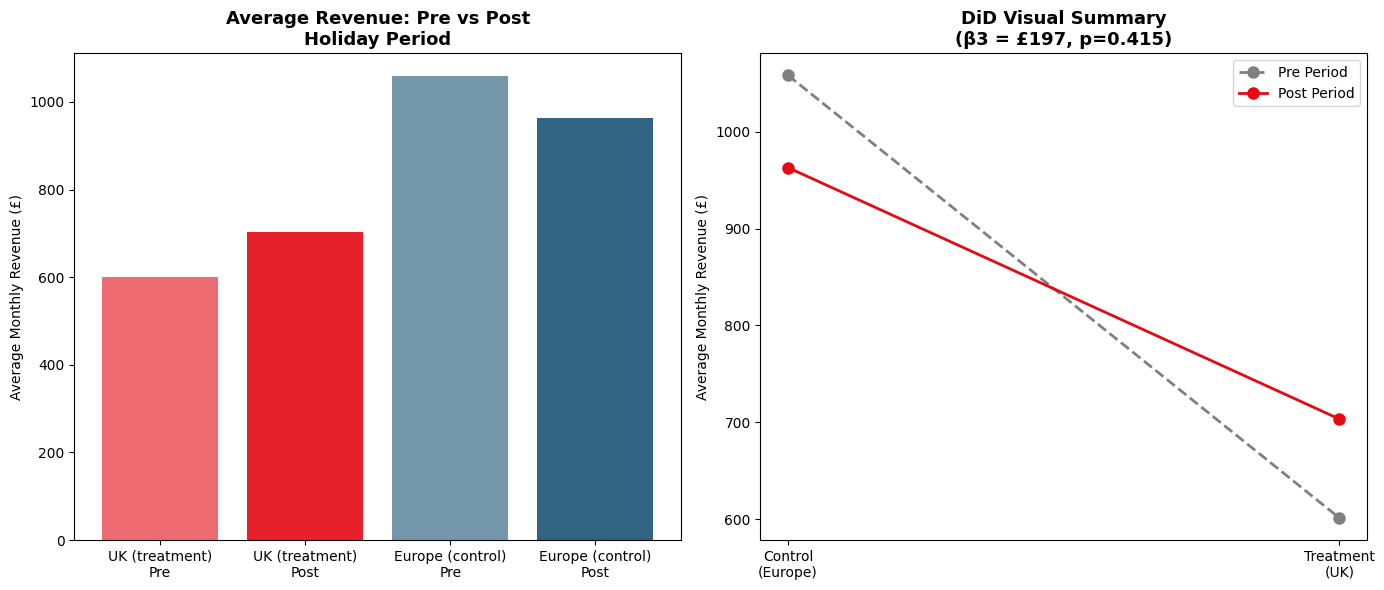

Results plot saved!


In [29]:
# Visualize the DiD result clearly
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 - Overall DiD
for treatment_val, label, color in [(1.0, 'UK (treatment)', '#E50914'),
                                      (0.0, 'Europe (control)', '#1A5276')]:
    data = mon_revenue[mon_revenue['treatment'] == treatment_val]
    pre_avg = data[data['post']==0]['mon_revenue'].mean()
    post_avg = data[data['post']==1]['mon_revenue'].mean()
    axes[0].bar([label + '\nPre'], [pre_avg], color=color, alpha=0.6)
    axes[0].bar([label + '\nPost'], [post_avg], color=color, alpha=0.9)

axes[0].set_title('Average Revenue: Pre vs Post\nHoliday Period', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Monthly Revenue (£)')

# Plot 2 - DiD summary
categories = ['Control\n(Europe)', 'Treatment\n(UK)']
pre_vals = [
    mon_revenue[(mon_revenue['treatment']==0) & (mon_revenue['post']==0)]['mon_revenue'].mean(),
    mon_revenue[(mon_revenue['treatment']==1) & (mon_revenue['post']==0)]['mon_revenue'].mean()
]
post_vals = [
    mon_revenue[(mon_revenue['treatment']==0) & (mon_revenue['post']==1)]['mon_revenue'].mean(),
    mon_revenue[(mon_revenue['treatment']==1) & (mon_revenue['post']==1)]['mon_revenue'].mean()
]

x = range(len(categories))
axes[1].plot(x, pre_vals, 'o--', color='gray', linewidth=2, markersize=8, label='Pre Period')
axes[1].plot(x, post_vals, 'o-', color='#E50914', linewidth=2, markersize=8, label='Post Period')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_title('DiD Visual Summary\n(β3 = £197, p=0.415)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Monthly Revenue (£)')
axes[1].legend()

plt.tight_layout()
plt.savefig('did_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results plot saved!")